In [ ]:
from pathlib import Path
import os, json, cv2, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
import albumentations as A

SAVE_DIR = Path("../second_project/attention_unet_experiment")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = SAVE_DIR / "best_attention_resunet_busi.pth"
LAST_MODEL_PATH = SAVE_DIR / "last_attention_resunet_busi.pth"
HISTORY_PATH = SAVE_DIR / "training_history.csv"
METRICS_PATH = SAVE_DIR / "test_metrics.json"
PLOTS_DIR = SAVE_DIR / "plots"
PRED_DIR = SAVE_DIR / "test_predictions"

PLOTS_DIR.mkdir(exist_ok=True)
PRED_DIR.mkdir(exist_ok=True)

print("Saving outputs to:", SAVE_DIR)

Saving outputs to: ../second_project/attention_unet_experiment


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Using device:", device)

Using device: mps


In [3]:
IMG_SIZE = 512

train_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),

    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=12, border_mode=cv2.BORDER_CONSTANT, p=0.5),

    A.Affine(
        scale=(0.90, 1.10),
        translate_percent=0.05,
        rotate=0,
        border_mode=cv2.BORDER_CONSTANT,
        p=0.5
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.20,
        p=0.4
    ),

    A.GaussianBlur(blur_limit=(3, 3), p=0.15),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.3),
])

val_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
])


In [ ]:
class ResidualConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(inplace=True),
        )

        self.skip = nn.Conv2d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        return self.dropout(self.conv(x) + self.skip(x))


class AttentionGate(nn.Module):
    def __init__(self, gate_ch, skip_ch, inter_ch):
        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(gate_ch, inter_ch, 1, bias=False),
            nn.GroupNorm(8, inter_ch)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(skip_ch, inter_ch, 1, bias=False),
            nn.GroupNorm(8, inter_ch)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(inter_ch, 1, 1),
            nn.Sigmoid()
        )

        self.relu = nn.SiLU(inplace=True)

    def forward(self, g, x):
        attn = self.relu(self.W_g(g) + self.W_x(x))
        attn = self.psi(attn)
        return x * attn


class AttentionResUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base=32):
        super().__init__()

        self.enc1 = ResidualConvBlock(in_channels, base)
        self.enc2 = ResidualConvBlock(base, base * 2)
        self.enc3 = ResidualConvBlock(base * 2, base * 4, dropout=0.05)
        self.enc4 = ResidualConvBlock(base * 4, base * 8, dropout=0.10)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = ResidualConvBlock(base * 8, base * 16, dropout=0.15)

        self.up4 = nn.ConvTranspose2d(base * 16, base * 8, 2, stride=2)
        self.att4 = AttentionGate(base * 8, base * 8, base * 4)
        self.dec4 = ResidualConvBlock(base * 16, base * 8, dropout=0.10)

        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.att3 = AttentionGate(base * 4, base * 4, base * 2)
        self.dec3 = ResidualConvBlock(base * 8, base * 4, dropout=0.05)

        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.att2 = AttentionGate(base * 2, base * 2, base)
        self.dec2 = ResidualConvBlock(base * 4, base * 2)

        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.att1 = AttentionGate(base, base, base // 2)
        self.dec1 = ResidualConvBlock(base * 2, base)

        self.out = nn.Conv2d(base, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        e4 = self.att4(d4, e4)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        e3 = self.att3(d3, e3)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        e2 = self.att2(d2, e2)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        e1 = self.att1(d1, e1)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.out(d1)

In [ ]:
class DiceFocalBCELoss(nn.Module):
    def __init__(self, bce_weight=0.25, dice_weight=0.55, focal_weight=0.20, gamma=2.0):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.focal_weight = focal_weight
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)

        bce_loss = self.bce(logits, targets)

        probs_flat = probs.view(probs.size(0), -1)
        targets_flat = targets.view(targets.size(0), -1)

        intersection = (probs_flat * targets_flat).sum(dim=1)
        dice = (2 * intersection + 1e-7) / (
            probs_flat.sum(dim=1) + targets_flat.sum(dim=1) + 1e-7
        )
        dice_loss = 1 - dice.mean()

        bce_per_pixel = F.binary_cross_entropy_with_logits(
            logits, targets, reduction="none"
        )
        pt = torch.exp(-bce_per_pixel)
        focal_loss = ((1 - pt) ** self.gamma * bce_per_pixel).mean()

        return (
            self.bce_weight * bce_loss +
            self.dice_weight * dice_loss +
            self.focal_weight * focal_loss
        )


def dice_iou_from_logits(logits, targets, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1) - intersection

    dice = (2 * intersection + 1e-7) / (
        preds.sum(dim=1) + targets.sum(dim=1) + 1e-7
    )
    iou = (intersection + 1e-7) / (union + 1e-7)

    return dice.mean().item(), iou.mean().item()

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None):
    model.train()

    total_loss, total_dice, total_iou = 0, 0, 0

    for images, masks in tqdm(loader, desc="Train", leave=False):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad(set_to_none=True)

        if scaler is not None:
            with torch.backends.mps.amp.autocast():
                logits = model(images)
                loss = criterion(logits, masks)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(images)
            loss = criterion(logits, masks)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        dice, iou = dice_iou_from_logits(logits.detach(), masks)

        total_loss += loss.item()
        total_dice += dice
        total_iou += iou

    n = len(loader)
    return total_loss / n, total_dice / n, total_iou / n


def evaluate_one_epoch(model, loader, criterion, device, threshold=0.5):
    model.eval()

    total_loss, total_dice, total_iou = 0, 0, 0

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Evaluate", leave=False):
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            loss = criterion(logits, masks)

            dice, iou = dice_iou_from_logits(logits, masks, threshold)

            total_loss += loss.item()
            total_dice += dice
            total_iou += iou

    n = len(loader)
    return total_loss / n, total_dice / n, total_iou / n

In [ ]:
model = AttentionResUNet(in_channels=1, out_channels=1, base=32).to(device)

criterion = DiceFocalBCELoss(
    bce_weight=0.25,
    dice_weight=0.55,
    focal_weight=0.20
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=8e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=10,
    T_mult=2,
    eta_min=1e-6
)

use_amp = torch.cuda.is_available()
scaler = torch.cuda.amp.GradScaler() if use_amp else None

num_epochs = 120
patience = 25
best_val_dice = -1
patience_counter = 0
history = []

if BEST_MODEL_PATH.exists():
    print("Saved model found. Loading best model...")
    checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    best_val_dice = checkpoint.get("best_val_dice", -1)
    history = checkpoint.get("history", [])

    model.eval()
    print(f"Loaded model with best validation Dice: {best_val_dice:.4f}")

else:
    print("No saved model found. Training from scratch...")

    for epoch in range(num_epochs):
        train_loss, train_dice, train_iou = train_one_epoch(
            model, train_loader, optimizer, criterion, device, scaler
        )

        val_loss, val_dice, val_iou = evaluate_one_epoch(
            model, val_loader, criterion, device, threshold=0.5
        )

        scheduler.step(epoch + val_dice)

        current_lr = optimizer.param_groups[0]["lr"]

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_dice": train_dice,
            "train_iou": train_iou,
            "val_loss": val_loss,
            "val_dice": val_dice,
            "val_iou": val_iou,
            "lr": current_lr
        })

        print(
            f"Epoch {epoch+1:03d}/{num_epochs} | "
            f"Train Loss={train_loss:.4f}, Dice={train_dice:.4f}, IoU={train_iou:.4f} | "
            f"Val Loss={val_loss:.4f}, Dice={val_dice:.4f}, IoU={val_iou:.4f} | "
            f"LR={current_lr:.6f}"
        )

        checkpoint = {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_val_dice": best_val_dice,
            "history": history,
            "config": {
                "model": "AttentionResUNet",
                "in_channels": 1,
                "out_channels": 1,
                "base": 32,
                "img_size": IMG_SIZE,
                "loss": "DiceFocalBCELoss",
                "optimizer": "AdamW",
                "lr": 8e-4,
                "weight_decay": 1e-4
            }
        }

        torch.save(checkpoint, LAST_MODEL_PATH)

        if val_dice > best_val_dice:
            best_val_dice = val_dice
            patience_counter = 0

            checkpoint["best_val_dice"] = best_val_dice
            torch.save(checkpoint, BEST_MODEL_PATH)

            print("Saved best model.")
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

    pd.DataFrame(history).to_csv(HISTORY_PATH, index=False)
    print("Training history saved to:", HISTORY_PATH)

No saved model found. Training from scratch...


Epoch 001/120 | Train Loss=0.5725, Dice=0.0879, IoU=0.0563 | Val Loss=0.5487, Dice=0.1050, IoU=0.0699 | LR=0.000800
Saved best model.


Epoch 002/120 | Train Loss=0.5291, Dice=0.2875, IoU=0.1873 | Val Loss=0.5129, Dice=0.3513, IoU=0.2331 | LR=0.000765
Saved best model.


Epoch 003/120 | Train Loss=0.4824, Dice=0.3812, IoU=0.2597 | Val Loss=0.5105, Dice=0.3448, IoU=0.2353 | LR=0.000696


Epoch 004/120 | Train Loss=0.4566, Dice=0.4205, IoU=0.2968 | Val Loss=0.4577, Dice=0.4372, IoU=0.3264 | LR=0.000589
Saved best model.


...

Epoch 085/120 | Train Loss=0.2248, Dice=0.7279, IoU=0.6190 | Val Loss=0.2127, Dice=0.7527, IoU=0.6430 | LR=0.000735


Epoch 086/120 | Train Loss=0.2296, Dice=0.7251, IoU=0.6165 | Val Loss=0.1901, Dice=0.7808, IoU=0.6826 | LR=0.000726


Epoch 087/120 | Train Loss=0.2144, Dice=0.7416, IoU=0.6373 | Val Loss=0.2105, Dice=0.7537, IoU=0.6467 | LR=0.000717


Epoch 088/120 | Train Loss=0.2127, Dice=0.7417, IoU=0.6371 | Val Loss=0.1886, Dice=0.7782, IoU=0.6747 | LR=0.000707


Epoch 089/120 | Train Loss=0.2079, Dice=0.7456, IoU=0.6405 | Val Loss=0.2038, Dice=0.7530, IoU=0.6491 | LR=0.000696
Early stopping triggered.
Training history saved to: ../second_project/attention_unet_experiment/training_history.csv


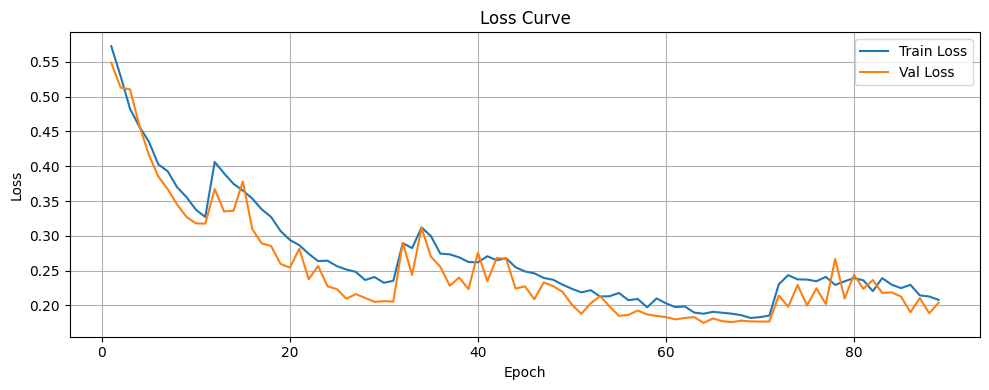

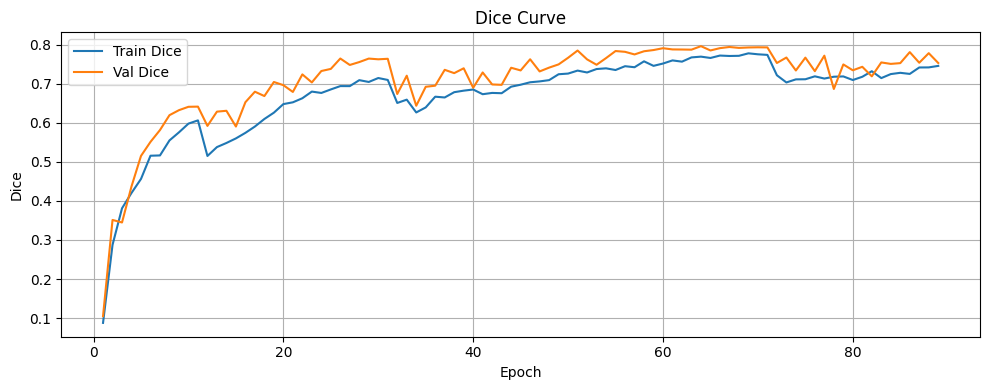

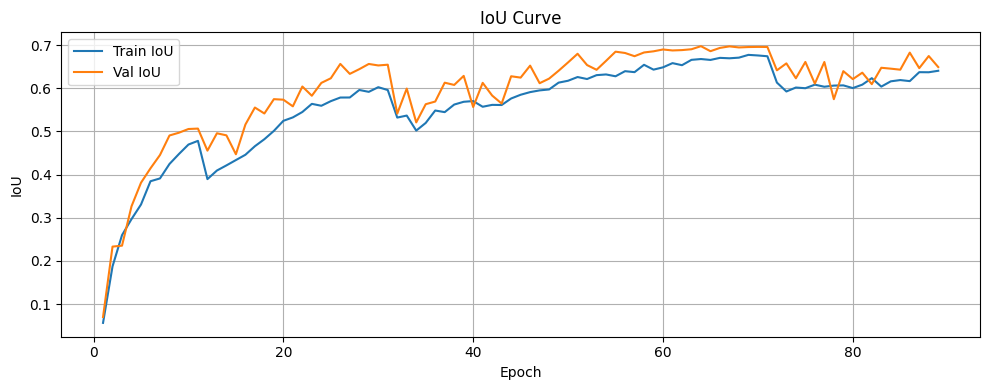

In [ ]:
hist_df = pd.DataFrame(history)

if len(hist_df) > 0:
    hist_df.to_csv(HISTORY_PATH, index=False)

    plt.figure(figsize=(10, 4))
    plt.plot(hist_df["epoch"], hist_df["train_loss"], label="Train Loss")
    plt.plot(hist_df["epoch"], hist_df["val_loss"], label="Val Loss")
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "loss_curve.png", dpi=300)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(hist_df["epoch"], hist_df["train_dice"], label="Train Dice")
    plt.plot(hist_df["epoch"], hist_df["val_dice"], label="Val Dice")
    plt.title("Dice Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Dice")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "dice_curve.png", dpi=300)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(hist_df["epoch"], hist_df["train_iou"], label="Train IoU")
    plt.plot(hist_df["epoch"], hist_df["val_iou"], label="Val IoU")
    plt.title("IoU Curve")
    plt.xlabel("Epoch")
    plt.ylabel("IoU")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "iou_curve.png", dpi=300)
    plt.show()
else:
    print("No history found. Model may have been loaded from checkpoint.")

In [ ]:
def evaluate_thresholds(model, loader, device, thresholds):
    model.eval()
    results = []

    with torch.no_grad():
        for th in thresholds:
            dices, ious = [], []

            for images, masks in loader:
                images = images.to(device)
                masks = masks.to(device)

                logits = model(images)
                dice, iou = dice_iou_from_logits(logits, masks, threshold=th)

                dices.append(dice)
                ious.append(iou)

            results.append({
                "threshold": float(th),
                "dice": float(np.mean(dices)),
                "iou": float(np.mean(ious))
            })

    return pd.DataFrame(results)


checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

thresholds = np.arange(0.30, 0.76, 0.05)
threshold_df = evaluate_thresholds(model, val_loader, device, thresholds)

threshold_df.to_csv(SAVE_DIR / "threshold_search.csv", index=False)

best_row = threshold_df.sort_values("dice", ascending=False).iloc[0]
best_threshold = float(best_row["threshold"])

print(threshold_df)
print("Best threshold:", best_threshold)
print("Best validation Dice:", best_row["dice"])
print("Best validation IoU:", best_row["iou"])

   threshold      dice       iou
0       0.30  0.794915  0.694199
1       0.35  0.796094  0.696231
2       0.40  0.796591  0.697471
3       0.45  0.796617  0.697877
4       0.50  0.796090  0.697535
5       0.55  0.795261  0.696737
6       0.60  0.793556  0.694814
7       0.65  0.790555  0.691183
8       0.70  0.786496  0.686316
9       0.75  0.779962  0.678948
Best threshold: 0.44999999999999996
Best validation Dice: 0.7966172099113464
Best validation IoU: 0.697876540514139


In [ ]:
test_loss, test_dice, test_iou = evaluate_one_epoch(
    model,
    test_loader,
    criterion,
    device,
    threshold=best_threshold
)

test_metrics = {
    "test_loss": float(test_loss),
    "test_dice": float(test_dice),
    "test_iou": float(test_iou),
    "best_threshold": float(best_threshold),
    "best_val_dice": float(best_val_dice)
}

with open(METRICS_PATH, "w") as f:
    json.dump(test_metrics, f, indent=4)

print("Final Test Results")
print(f"Loss: {test_loss:.4f}")
print(f"Dice: {test_dice:.4f}")
print(f"IoU : {test_iou:.4f}")
print("Saved metrics to:", METRICS_PATH)

Final Test Results
Loss: 0.2283
Dice: 0.7272
IoU : 0.6258
Saved metrics to: ../second_project/attention_unet_experiment/test_metrics.json


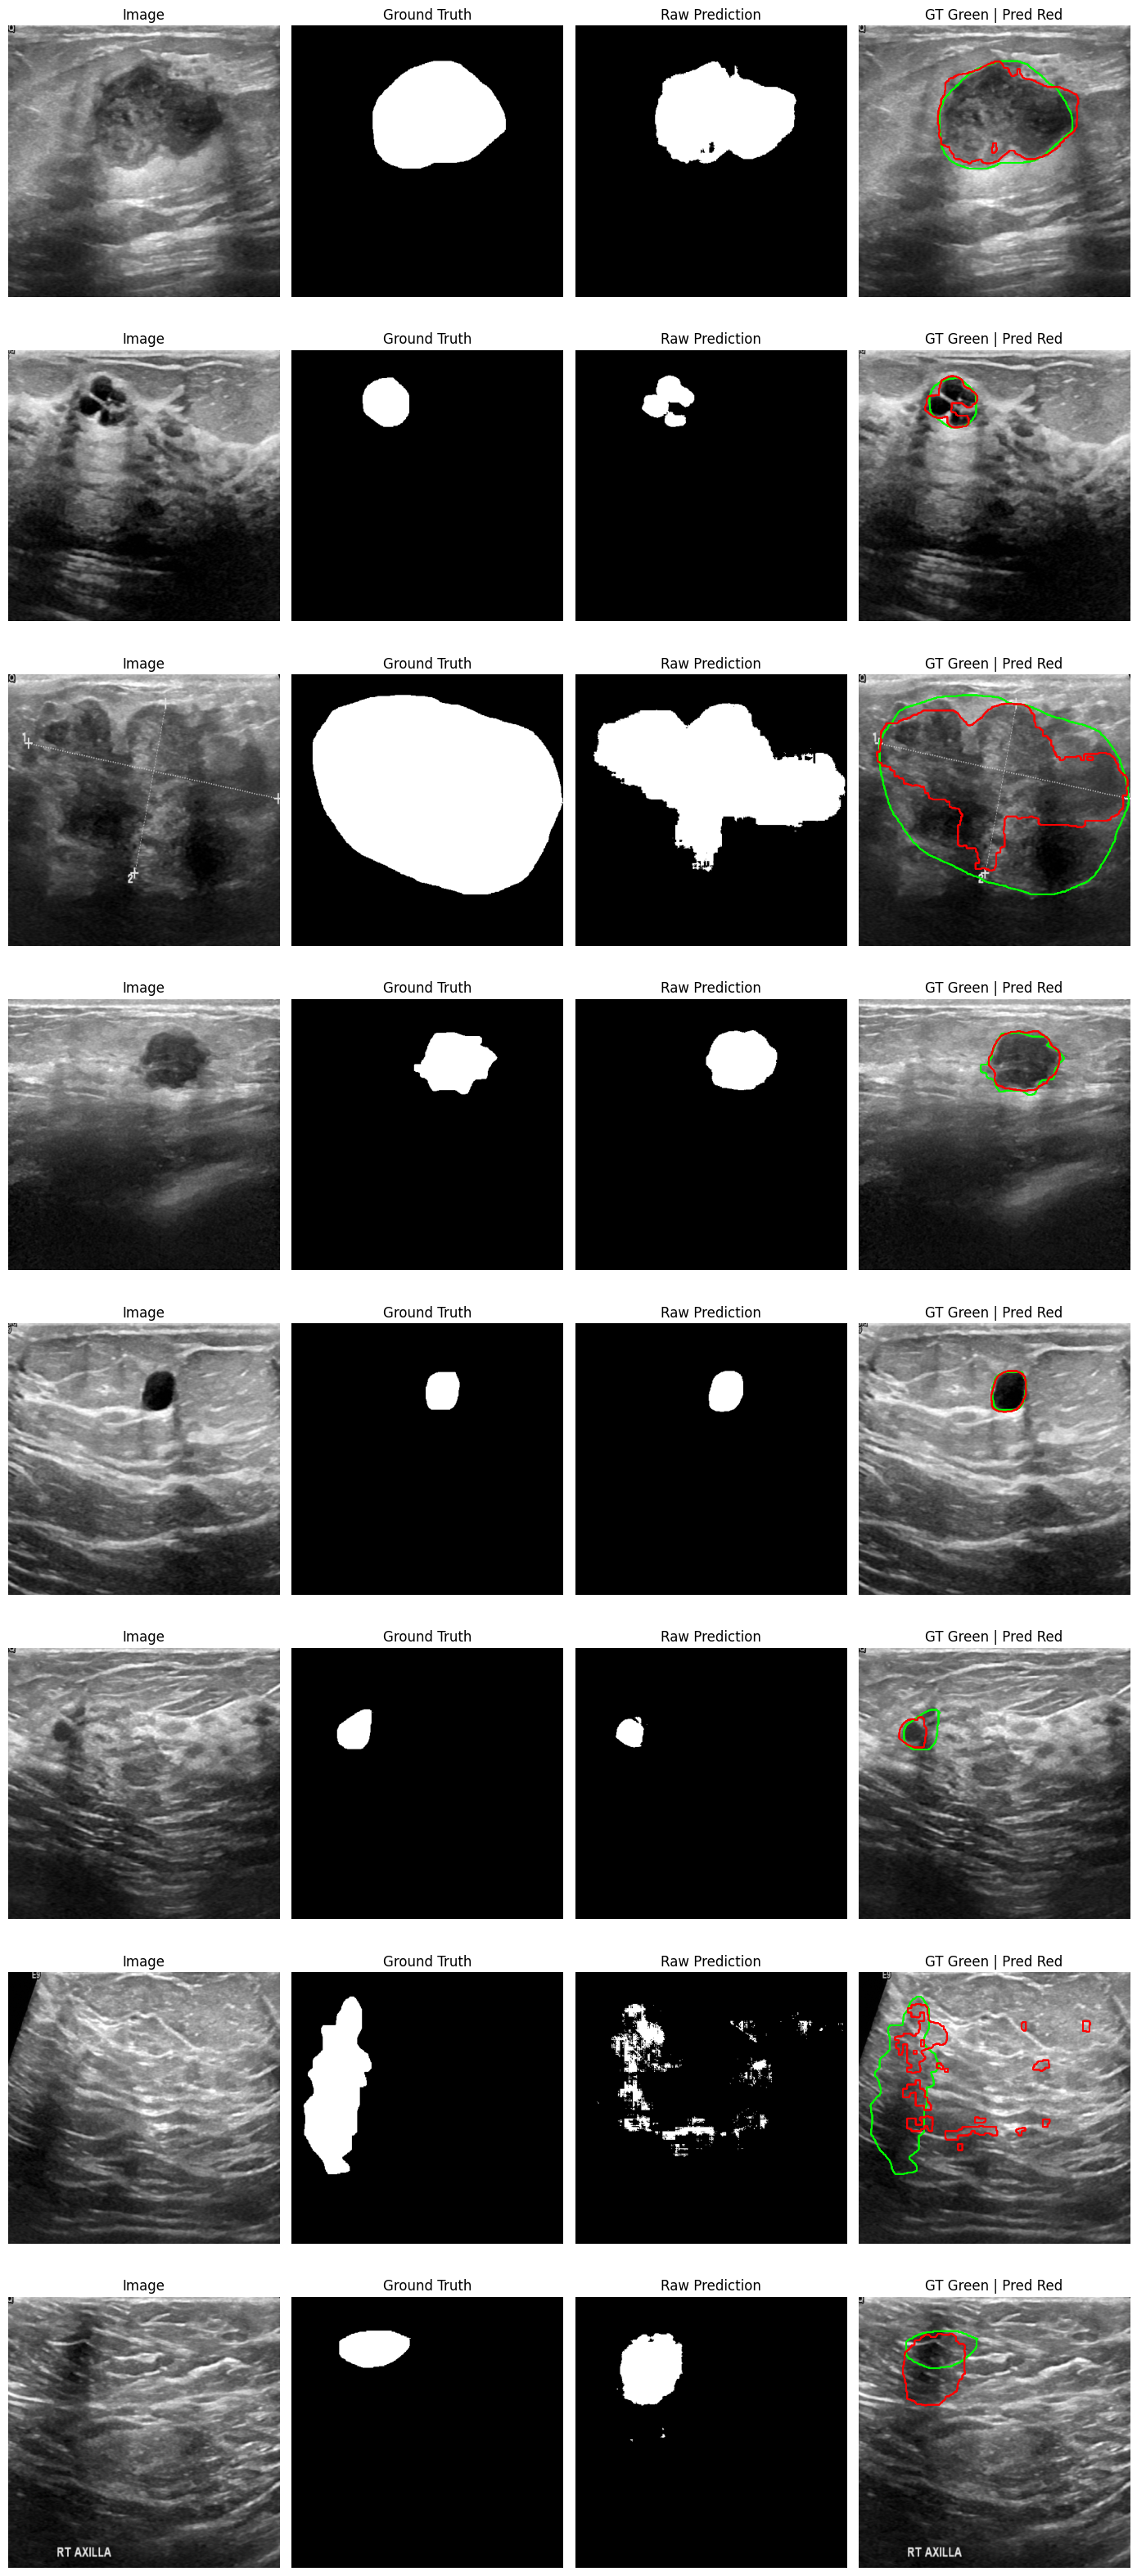

In [ ]:
def clean_mask(mask, min_area=100):
    mask = (mask > 0).astype(np.uint8)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    cleaned = np.zeros_like(mask)

    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]

        if area >= min_area:
            cleaned[labels == i] = 1

    kernel = np.ones((5, 5), np.uint8)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_OPEN, kernel)

    return cleaned


def visualize_predictions(model, dataset, n=8, threshold=0.5, save=True):
    model.eval()

    indices = np.random.choice(len(dataset), size=min(n, len(dataset)), replace=False)

    plt.figure(figsize=(14, 4 * len(indices)))

    with torch.no_grad():
        for row_idx, idx in enumerate(indices):
            image, gt_mask = dataset[idx]

            inp = image.unsqueeze(0).to(device)
            logits = model(inp)

            prob = torch.sigmoid(logits).squeeze().cpu().numpy()
            pred = (prob > threshold).astype(np.uint8)
            pred_clean = clean_mask(pred)

            img_np = image.squeeze().cpu().numpy()
            gt_np = gt_mask.squeeze().cpu().numpy()

            plt.subplot(len(indices), 4, row_idx * 4 + 1)
            plt.imshow(img_np, cmap="gray")
            plt.title("Image")
            plt.axis("off")

            plt.subplot(len(indices), 4, row_idx * 4 + 2)
            plt.imshow(gt_np, cmap="gray")
            plt.title("Ground Truth")
            plt.axis("off")

            plt.subplot(len(indices), 4, row_idx * 4 + 3)
            plt.imshow(pred, cmap="gray")
            plt.title("Raw Prediction")
            plt.axis("off")

            plt.subplot(len(indices), 4, row_idx * 4 + 4)
            plt.imshow(img_np, cmap="gray")
            plt.contour(gt_np, colors="lime", linewidths=1)
            plt.contour(pred_clean, colors="red", linewidths=1)
            plt.title("GT Green | Pred Red")
            plt.axis("off")

            if save:
                cv2.imwrite(
                    str(PRED_DIR / f"sample_{idx}_prediction.png"),
                    (pred_clean * 255).astype(np.uint8)
                )

    plt.tight_layout()

    if save:
        plt.savefig(PLOTS_DIR / "test_prediction_visualization.png", dpi=300)

    plt.show()


visualize_predictions(
    model,
    test_ds,
    n=8,
    threshold=best_threshold,
    save=True
)

In [ ]:
model = AttentionResUNet(in_channels=1, out_channels=1, base=32).to(device)

checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

history = checkpoint.get("history", [])
config = checkpoint.get("config", {})

print("Loaded saved model.")
print("Best validation Dice:", checkpoint.get("best_val_dice"))
print("Config:", config)

Loaded saved model.
Best validation Dice: 0.7960896033507127
Config: {'model': 'AttentionResUNet', 'in_channels': 1, 'out_channels': 1, 'base': 32, 'img_size': 512, 'loss': 'DiceFocalBCELoss', 'optimizer': 'AdamW', 'lr': 0.0008, 'weight_decay': 0.0001}
